In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from joblib import load
from tqdm import tqdm
import warnings

from sklearn.metrics import classification_report
warnings.filterwarnings("ignore")
import glob
import os
from collections import OrderedDict 
 
import numpy as np
import matplotlib.pyplot as plt  

import pandas as pd 


In [5]:
import yaml
import numpy as np
from src.data.modules.LitData  import LitData
from src.layers.ClassifierBaseModel import ClassifierBaseModel
from src.layers.classifiers import TokenClassifier
from src.layers.transformer.lightcurve import LightCurveTransformer

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import numpy as np
DICT = {
    "AGN": 0,
    "QSO": 1,
    "EA": 2,
    "YSO": 3,
    "SNIa": 4,
    "CV/Nova": 5,
    "RRLc": 6,
    "RSCVn": 7,
    "Blazar": 8,
    "SNII": 9,
    "EB/EW": 10,
    "LPV": 11,
    "CEP": 12,
    "RRLab": 13,
    "Periodic-Other": 14,
    "DSCT": 15,
    "SNIbc": 16,
    "SLSN": 17,
    "TDE": 18,
    "SNIIb": 19,
    "SNIIn": 20,
    "Microlensing": 21
    }
def produce_report(path_1):
    path_args = glob.glob(f"{path_1}*args*")[0]
    #print(path_args)
   
    with open(path_args, 'r') as file:
        args = yaml.safe_load(file)
    #print('Initializing models') 
    
    model = ClassifierBaseModel(model = LightCurveTransformer(**args['lc']), classifier=TokenClassifier(**args['lc'],num_classes=args['general']['num_classes']) )
    #print('Loading checkpoints')
    checkpoint_path_clip = glob.glob(
        f"{path_1}*my_best_checkpoint*"
    ) 
    #print(checkpoint_path_clip[-1])
    checkpoint_clip = torch.load(checkpoint_path_clip[-1], map_location=torch.device('cuda:2'))
    od_atat = OrderedDict() 
    for key in checkpoint_clip["state_dict"].keys(): 

        od_atat[key.replace("", "")] = checkpoint_clip["state_dict"][key]

    model.load_state_dict(od_atat,strict=True)
    args['general']['data_root'] = 'data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12'
    args['general']['use_sampler'] = False
    args['general']['batch_size'] = 256

    pl_datal = LitData(dataset_config_dict =  {'use_lightcurves':args['general']['use_lightcurves'], 
                                        'use_lightcurves_err':False,
                                        'use_metadata':args['general']['use_metadata'],
                                        'use_features':args['general']['use_features'],
                                        'seed':args['general']['seed'],
                                        'train_apply_transform':True,
                                        'validation_apply_transform':False,
                                        'transforms': [],
                                        'data_root':args['general']['data_root'] },**args['general'])
    dataloader = pl_datal.test_dataloader() 
    target = None
    preds_out = None

    model.eval().to(device = 'cuda:2')  

    for b1 in tqdm(dataloader):

        #print(b1.keys())
        b1 = {key:value.to(device = 'cuda:2') for key, value in b1.items()}
        t = b1.pop('labels')
        #print(b1['mask'].sum(dim = [1,2])[0])
        lc_emb = model(**b1)  
        
        preds_out = (
            np.concatenate([preds_out, torch.argmax(lc_emb, axis=1).detach().cpu().numpy()])
            if preds_out is not None
            else torch.argmax(lc_emb, axis=1).cpu().detach().numpy()
        )
        target = (
            np.concatenate([target, t.cpu().detach().numpy()])
            if target is not None
            else t.detach().cpu().numpy()
        )
    results = preds_out
    classification = classification_report(target, results, target_names=list(DICT.keys()),digits = 4)
    print(classification)
    data_dict =  classification_report(target, results, target_names=list(DICT.keys()),digits = 4, output_dict=True)    
    from src.utils.plots.ATATConfusionMatrix import elasticc_confusion_matrix
    out_metrics_balto = classification_report(
        target, results, target_names=list(DICT.keys()), output_dict=True
    )["macro avg"]
    template_balto = ""
    for key in out_metrics_balto.keys():
        template_balto += " {} : {:.3f} ".format(key.upper(), out_metrics_balto[key])
    fig, axes = plt.subplots(1, 1, figsize=(12, 12))
    elasticc_confusion_matrix(
        y_true=np.array(target).astype(int),
        y_pred=np.array(results).astype(int),
        classes= np.array(list(DICT.keys())),
        ax=axes,
        normalize=True,
        title=f" FClassifier Results [TEST] \n\n {template_balto}",
    )
    plt.show()
     
    return data_dict

In [3]:
path_1  = '/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/ZTF_ff/LC/finetune_new_projectors_trans_v0_0/'
path_2 = '/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/ZTF_ff/LC/TEST_residual_0/'

100%|██████████| 197/197 [00:16<00:00, 11.81it/s]


                precision    recall  f1-score   support

           AGN     0.4616    0.3328    0.3868      3933
           QSO     0.5634    0.6004    0.5813      4099
            EA     0.8096    0.7270    0.7661      4352
           YSO     0.5782    0.5994    0.5886      3295
          SNIa     0.4855    0.4574    0.4711      2162
       CV/Nova     0.6520    0.5802    0.6140      1944
          RRLc     0.7949    0.7416    0.7673      4233
         RSCVn     0.6246    0.6637    0.6436      3119
        Blazar     0.3338    0.3864    0.3582      1703
          SNII     0.2998    0.3963    0.3414      1037
         EB/EW     0.7057    0.7636    0.7335      4607
           LPV     0.8427    0.7707    0.8051      4135
           CEP     0.6530    0.6821    0.6672      3507
         RRLab     0.7896    0.6568    0.7171      4423
Periodic-Other     0.5436    0.5722    0.5575       872
          DSCT     0.4578    0.7650    0.5728      2051
         SNIbc     0.1767    0.2286    0.1993  

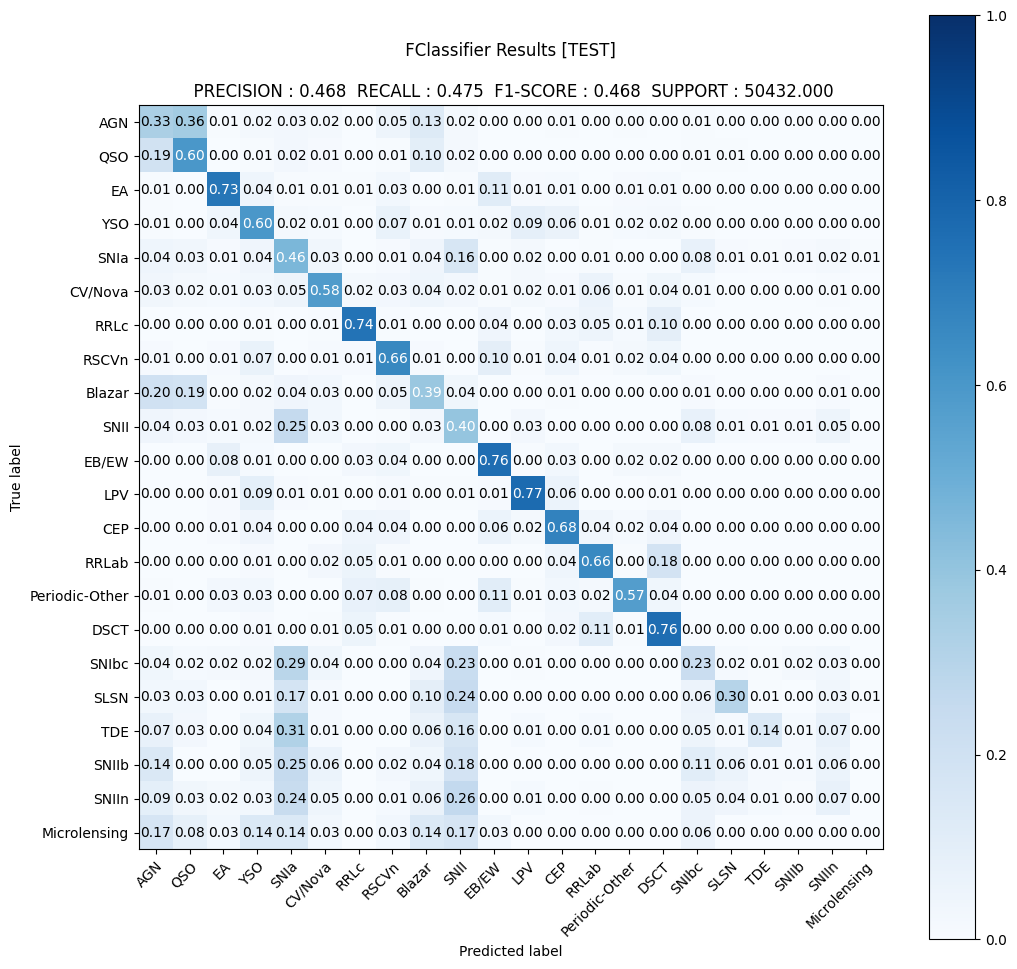

In [6]:
data_dict_1 = produce_report(path_1)

In [12]:
data_dict_2 = produce_report(path_2)

IndexError: list index out of range

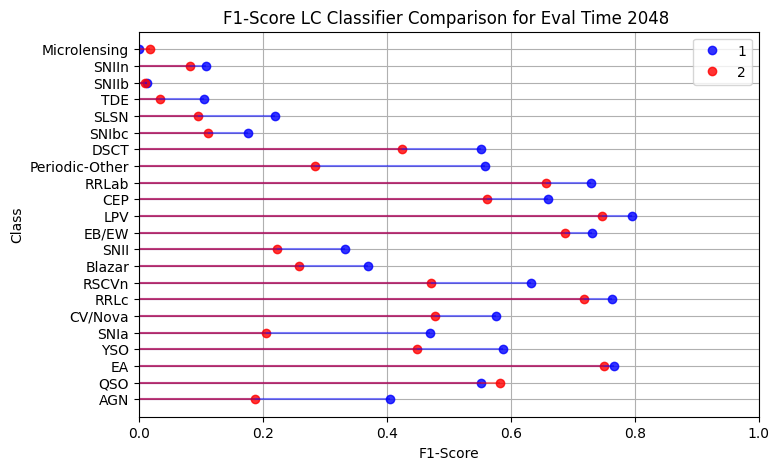

In [19]:
def compare_models(d1,d2, eval_time= 2048):

    f1_baseline = []
    f1_finetune = []

    fig,ax = plt.subplots(1,1,figsize = (8,5))
    for key,value in data_dict_1.items():
        if key in DICT.keys():
            #print(key,value)
            f1_baseline.append(value['f1-score'])
    df_1 = pd.DataFrame({'group':DICT.keys(), 'values':f1_baseline })
    ordered_df_1 = df_1#.sort_values(by='values')
    my_range_1=range(1,len(df_1.index)+1)
    

    for key,value in data_dict_2.items():
        if key in DICT.keys():
            #print(key,value)
            f1_finetune.append(value['f1-score'])
    df_2 = pd.DataFrame({'group':DICT.keys(), 'values':f1_finetune})
    ordered_df_2 = df_2#.sort_values(by='values')
    my_range_2=range(1,len(df_2.index)+1)
    plt.plot(ordered_df_1['values'].values, my_range_1, "o", alpha = 0.8,color='blue')
    plt.plot(ordered_df_2['values'].values, my_range_2, "o", alpha = 0.8,color='red')

    plt.legend(['1','2'])
    
    # The horizontal plot is made using the hline function
    plt.hlines(y=my_range_1, xmin=0, xmax=ordered_df_1['values'], color='blue', alpha = 0.5)
    
    # The horizontal plot is made using the hline function
    plt.hlines(y=my_range_2, xmin=0, xmax=ordered_df_2['values'], color='red', alpha = 0.5)

    # Add titles and axis names
    plt.yticks(my_range_1, ordered_df_1['group'])
    plt.title(f"F1-Score LC Classifier Comparison for Eval Time {eval_time} ", loc='center')

    plt.xlabel('F1-Score')
    plt.ylabel('Class')
    plt.xlim(0,1)
    #plt.xticks(np.arange(0,1,50), ordered_df_1['group'])
    plt.grid('on', )
    # Show the plot
    plt.show()
compare_models(data_dict_1,data_dict_2)

In [16]:
transient =  {
    "SNIa": 4,
    "SNII": 9,
    "SNIbc": 16,
    "SLSN": 17,
    "TDE": 18,
    "SNIIb": 19,
    "SNIIn": 20,
    "Microlensing": 21
}
stochastic =  {
    "AGN": 0,
    "QSO": 1,
    "YSO": 3,
    "CV/Nova": 5,
    "Blazar": 8,
}
periodic =  {
    "EA": 2,
    "RRLc": 6,
    "RSCVn": 7,
    "EB/EW": 10,
    "LPV": 11,
    "CEP": 12,
    "RRLab": 13,
    "Periodic-Other": 14,
    "DSCT": 15,
}

In [17]:

trans_f1 = []
stoch_f1 = []
per_f1 = []
for class_key, value in data_dict_1.items():
    #print(class_key)
    if class_key in DICT.keys():
        
        if class_key in transient.keys():
            trans_f1.append(value['f1-score'])
        if class_key in stochastic.keys():
            stoch_f1.append(value['f1-score'])
        if class_key in periodic.keys():
            per_f1.append(value['f1-score'])
print('group eval:')
print('trans',np.mean(trans_f1))
print('stoch',np.mean(stoch_f1))

print('per',np.mean(per_f1))


group eval:
trans 0.09137402124221418
stoch 0.3075233844676247
per 0.44516766236377314


In [18]:

trans_f1 = []
stoch_f1 = []
per_f1 = []
for class_key, value in data_dict_2.items():
    #print(class_key)
    if class_key in DICT.keys():
        
        if class_key in transient.keys():
            trans_f1.append(value['f1-score'])
        if class_key in stochastic.keys():
            stoch_f1.append(value['f1-score'])
        if class_key in periodic.keys():
            per_f1.append(value['f1-score'])
print('group eval:')    
print('trans',np.mean(trans_f1))
print('stoch',np.mean(stoch_f1))
print('per',np.mean(per_f1))

group eval:
trans 0.09057053026767672
stoch 0.3213394733576514
per 0.46253493405430646


In [19]:
adfadf

NameError: name 'adfadf' is not defined

In [21]:
def early_as(path_1:str, before_time:int,supress_cm = False,supress_dict = False):
    path_args = glob.glob(f"{path_1}*args*")[0]
    #print(path_args)
    with open(path_args, 'r') as file:
        args = yaml.safe_load(file)
    #print('Initializing models') 
    model = LightCurveClassifier(**args) 
    #print('Loading checkpoints')
    checkpoint_path_clip = glob.glob(
        f"{path_1}*my_best_checkpoint*"
    ) 
    #print(checkpoint_path_clip[-1])
    checkpoint_clip = torch.load(checkpoint_path_clip[-1], map_location=torch.device('cuda:2'))
    od_atat = OrderedDict() 
    for key in checkpoint_clip["state_dict"].keys(): 
            #print(key)
            if 'project' in key:
                continue
            if 'model' in key:
                od_atat[key.replace("model.", "")] = checkpoint_clip["state_dict"][key]

    model.load_state_dict(od_atat,strict=True)
    args['general']['data_root'] = 'data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12'
    args['general']['use_sampler'] = False
    args['general']['batch_size'] = 256

    pl_datal = LitData(**args['general'])
    dataloader = pl_datal.test_dataloader() 
    target = None
    preds_out = None

    model.eval().to(device = 'cuda:2')  

    for b1 in tqdm(dataloader):

        #print(b1.keys())
        b1 = {key:value.to(device = 'cuda:2') for key, value in b1.items()}
        #print(b1['time'].shape,b1['mask'].shape)
        #b1['data'][:,before_time:,:] = 0
        #b1['time'][:,before_time:,:] = 0
        #b1['mask'] = (b1['data'] !=0)
        mask = torch.ones_like(b1['mask'])
        #mask[before_time:,:] = 0 
        #b1['mask'] = b1['mask'] * mask
        lc_emb = model(**b1)  
        t = b1['labels']
        preds_out = (
            np.concatenate([preds_out, torch.argmax(lc_emb, axis=1).detach().cpu().numpy()])
            if preds_out is not None
            else torch.argmax(lc_emb, axis=1).cpu().detach().numpy()
        )
        target = (
            np.concatenate([target, t.cpu().detach().numpy()])
            if target is not None
            else t.detach().cpu().numpy()
        )
    results = preds_out
    classification = classification_report(target, results, target_names=list(DICT.keys()),digits = 4)
    data_dict =  classification_report(target, results, target_names=list(DICT.keys()),digits = 4, output_dict=True)    
    if supress_dict == 0:
        print(classification)
    if supress_cm == 0:        
        from src.utils.plottinglib import elasticc_confusion_matrix
        out_metrics_balto = classification_report(
            target, results, target_names=list(DICT.keys()), output_dict=True
        )["macro avg"]
        template_balto = ""
        for key in out_metrics_balto.keys():
            template_balto += " {} : {:.3f} ".format(key.upper(), out_metrics_balto[key])
        fig, axes = plt.subplots(1, 1, figsize=(12, 12))
        elasticc_confusion_matrix(
            y_true=np.array(target).astype(int),
            y_pred=np.array(results).astype(int),
            classes= np.array(list(DICT.keys())),
            ax=axes,
            normalize=True,
            
            title=f" FClassifier Results [TEST] \n\n {template_balto}",
        )
        plt.show()
    
    return data_dict

In [22]:
data_dict_1['macro avg']['f1-score']

0.285232638797718

In [23]:
e_times = [10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,200]
macro_f1_eval_times = {'d1':[],'d2':[]}
for eval_time in e_times:
    data_dict_1 = early_as(path_1, before_time = eval_time,supress_cm=True,supress_dict=True)
    data_dict_2 = early_as(path_2, before_time = eval_time,supress_cm=True,supress_dict=True)
    macro_f1_eval_times['d1'].append(data_dict_1['macro avg']['f1-score'])
    macro_f1_eval_times['d2'].append(data_dict_2['macro avg']['f1-score'])
    compare_models(data_dict_1,data_dict_2,eval_time)

data_dict_1 = produce_report(path_1)
data_dict_2 = produce_report(path_2) 

using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


 20%|█▉        | 39/197 [00:03<00:15, 10.22it/s]


KeyboardInterrupt: 

In [15]:
import seaborn as sns

sns.lineplot(macro_f1_eval_times[::-1])
#plt.legend(['baseline','pretrained'])

plt.title('F1-score for ')
plt.xticks(list(range(len(e_times))),[str(time) for time in e_times])
plt.xlabel('Max Evaluated Time')
plt.ylabel('F1-score')
plt.grid('on')

KeyError: slice(None, None, -1)

modl is not sample dependent